# K Means Clustering

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/8bd6144a87988213693754baaa13fb204933282d/Mall_Customers.csv")

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling (important for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

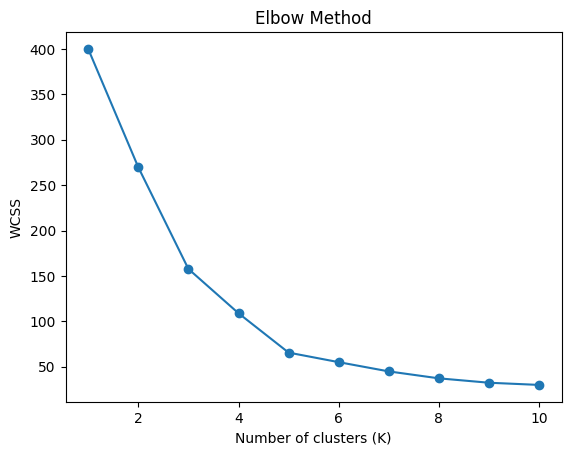

In [ ]:
# Find optimal K using Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [ ]:
# Fit final model (commonly K=5)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = labels

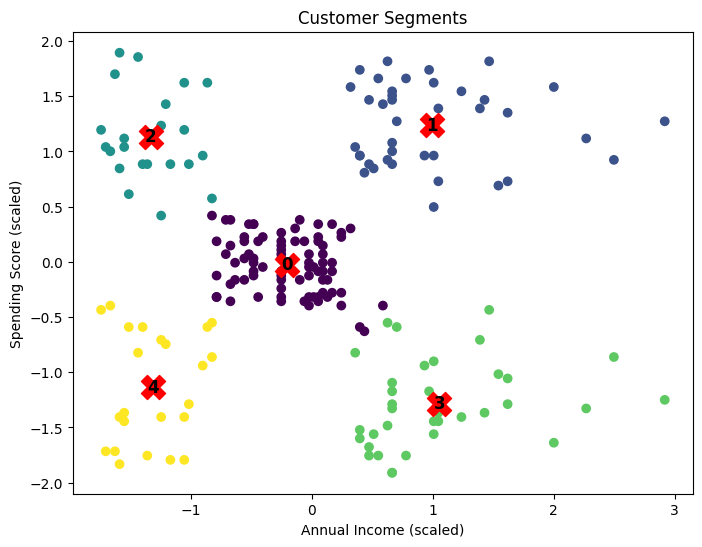

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis')

centers = kmeans.cluster_centers_

# plot centroids
plt.scatter(centers[:,0], centers[:,1], s=300, c='red', marker='X')

# add cluster labels
for i, center in enumerate(centers):
    plt.text(center[0], center[1], str(i),
             fontsize=12, fontweight='bold',
             color='black',
             ha='center', va='center')

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Customer Segments")
plt.show()

In [ ]:
df.groupby('Cluster')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,81.0,42.716049,16.447822,18.0,27.00,46.0,54.00,70.0
1,39.0,32.692308,3.728650,27.0,30.00,32.0,35.50,40.0
2,22.0,25.272727,5.257030,18.0,21.25,23.5,29.75,35.0
3,35.0,41.114286,11.341676,19.0,34.00,42.0,47.50,59.0
4,23.0,45.217391,13.228607,19.0,35.50,46.0,53.50,67.0


In [ ]:
df.groupby('Cluster')['Age'].mean()

,Age
Cluster,
0,42.716049
1,32.692308
2,25.272727
3,41.114286
4,45.217391


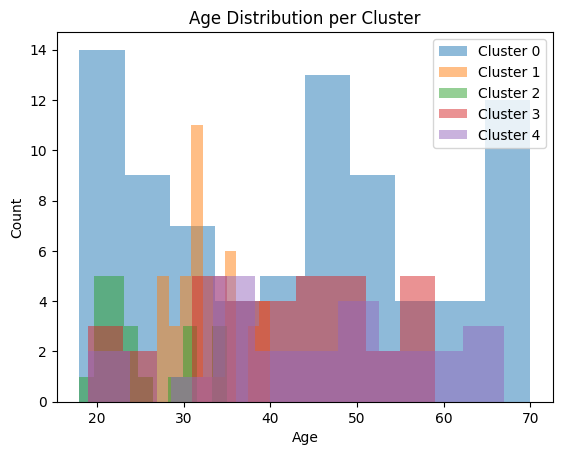

In [ ]:
import matplotlib.pyplot as plt

for c in sorted(df['Cluster'].unique()):
    plt.hist(df[df['Cluster'] == c]['Age'], alpha=0.5, label=f'Cluster {c}')

plt.legend()
plt.title("Age Distribution per Cluster")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [ ]:
pd.crosstab(df['Cluster'], df['Gender'])

Gender,Female,Male
Cluster,,
0,48,33
1,21,18
2,13,9
3,16,19
4,14,9


In [ ]:
gender_dist = pd.crosstab(df['Cluster'], df['Gender'], normalize='index') * 100
gender_dist

Gender,Female,Male
Cluster,,
0,59.259259,40.740741
1,53.846154,46.153846
2,59.090909,40.909091
3,45.714286,54.285714
4,60.869565,39.130435


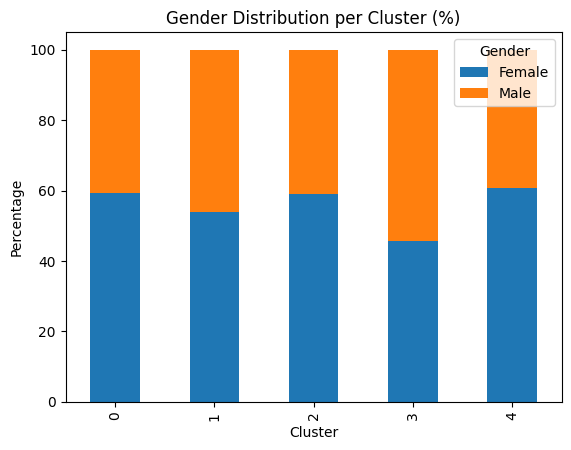

In [ ]:
gender_dist.plot(kind='bar', stacked=True)
plt.title("Gender Distribution per Cluster (%)")
plt.ylabel("Percentage")
plt.show()

## Buisness Interpretetion

🟣 Cluster 2: Young-heavy cluster
- Mostly age 18–30
- High spending score

👉 Interpretation:

Trend-driven, impulsive buyers

🔵 Cluster 1: Older high-income group
- Age 40–60
- High income but variable spending

👉 Interpretation:

Conservative but premium-targetable customers

🟢 Cluster 0: Gender skewed cluster
- e.g., more female customers in high spending cluster

👉 Interpretation:

Product-category targeting opportunity

## Principal Component Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------
# Load dataset from GitHub raw
# -----------------------------
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

df = pd.read_csv(url)

df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:

# -----------------------------
# Split features and target
# -----------------------------
X = df.drop("species", axis=1)

# convert categorical target to numeric
y = df["species"].astype("category").cat.codes

# -----------------------------
# Standardize features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Apply PCA
# -----------------------------
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


In [ ]:
# -----------------------------
# Variance analysis
# -----------------------------
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Format output
print("\nExplained variance ratio:")
print([f"{x:.2f}" for x in explained_variance])

print("\nCumulative explained variance:")
print([f"{x:.2f}" for x in cumulative_variance])

# -----------------------------
# Highlight key insight (colored)
# -----------------------------
print("\n\033[1;32mTwo principal components explain ~96% of the variance.\033[0m")
print("\033[1;34mSo we can reduce 4D data → 2D with minimal information loss.\033[0m")


Explained variance ratio:
['0.73', '0.23', '0.04', '0.01']

Cumulative explained variance:
['0.73', '0.96', '0.99', '1.00']

Two principal components explain ~96% of the variance.
So we can reduce 4D data → 2D with minimal information loss.


In [ ]:
variance = information

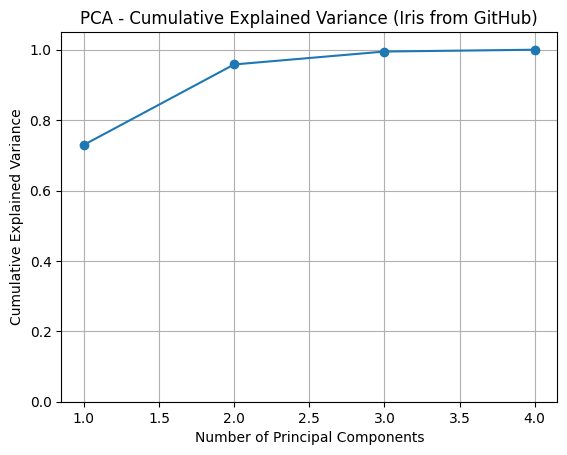

In [ ]:
# -----------------------------
# Plot cumulative variance
# -----------------------------
plt.figure()
plt.plot(range(1, len(cumulative_variance) + 1),
         cumulative_variance,
         marker='o')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance (Iris from GitHub)")
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()


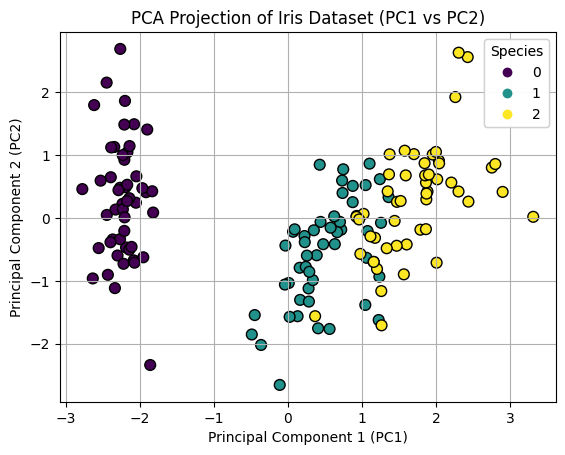

In [ ]:
# -----------------------------
# Plot PC1 vs PC2
# -----------------------------
plt.figure()

scatter = plt.scatter(
    X_pca[:, 0],  # first principal component -> 1st new feature
    X_pca[:, 1],
    c=y,
    cmap="viridis",
    edgecolor="k",
    s=60
)

plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("PCA Projection of Iris Dataset (PC1 vs PC2)")
plt.grid(True)

# legend
legend1 = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=list(y.unique()),
    title="Species"
)

plt.gca().add_artist(legend1)

plt.show()